$$
\bigstar\;\diamond\;\bigstar\quad\boxed{\sigma_{\omega}\sigma}\quad\bigstar\;\diamond\;\bigstar
$$

# 图 3.4

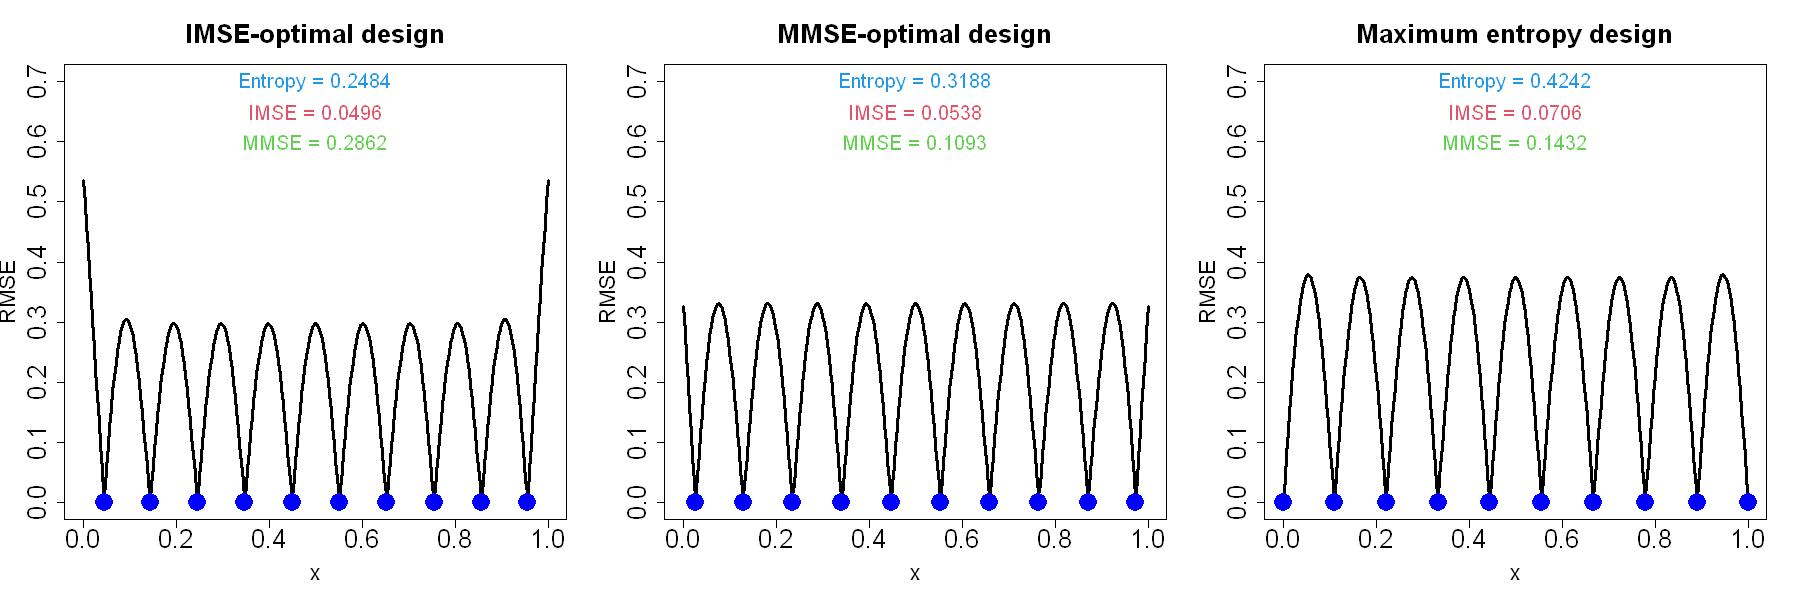

$$
\bigstar\;\diamond\;\bigstar\quad\boxed{\sigma_{\omega}\sigma}\quad\bigstar\;\diamond\;\bigstar
$$

## 背景信息

针对一维算例,取相关函数 $R(x)=\exp(-x^{2}/\theta^{2})$,尺度参数 $\theta=0.1$,求解得到含 10 次试验的熵设计,该设计及其对应的均方根误差曲线绘制于图 3.4 右侧子图;图中同时附上图 3.2 中的积分均方误差最优设计与最大均方误差最优设计,便于直观对比.可以发现,相较于积分均方误差最优设计与最大均方误差最优设计,熵设计的试验点向区间边界偏移;该最大熵设计与图 3.2 中的等距设计分布相近,但全局最大均方根误差更小.

$$
\bigstar\;\diamond\;\bigstar\quad\boxed{\sigma_{\omega}\sigma}\quad\bigstar\;\diamond\;\bigstar
$$

## 指令

定义高斯核函数 `r(x,D)`.利用公式 $$s(\boldsymbol{x})=\sqrt{1-\boldsymbol{r}(\boldsymbol{x})'\boldsymbol{R}^{-1}\boldsymbol{r}(\boldsymbol{x})}$$ 定义 RMSE 函数 `s(x)`.利用公式 $$\mathrm{IMSE}(D;\boldsymbol{\theta})=\int_{\mathcal{X}}(1-\boldsymbol{r}(\boldsymbol{x})'\boldsymbol{R}^{-1}\boldsymbol{r}(\boldsymbol{x}))\mathrm{d}\boldsymbol{x}$$ 定义 IMSE 函数 `imse(D)`.利用公式 $$\mathrm{MMSE}(D;\boldsymbol{\theta})=\max_{\boldsymbol{x}\in\mathcal{X}}(1-\boldsymbol{r}(\boldsymbol{x})'\boldsymbol{R}^{-1}\boldsymbol{r}(\boldsymbol{x}))$$ 定义 MMSE 函数 `mmse(D)`.利用公式 $$\mathrm{Ent}(\boldsymbol{y}):=|\boldsymbol{R}|$$ 定义 Ent 函数 `ent(D)`.

```r
r=function(x,D)exp(-(outer(x,D,"-")/theta)^2)
s=function(x){
  Z=solve(R+10^(-6)*diag(n),t(r(x,D)))
  sqrt(1-colSums(t(r(x,D))*Z))
}
imse=function(D){
  R=r(D,D)
  s=function(x){
    Z=solve(R+10^(-6)*diag(n),t(r(x,D)))
    1-colSums(t(r(x,D))*Z)
  }
  integrate(s,0,1)$val
}
mmse=function(D){
  R=r(D,D)
  s=function(x){
    Z=solve(R+10^(-6)*diag(n),t(r(x,D)))
    1-colSums(t(r(x,D))*Z)
  }
  test=seq(0,1,length=301)
  max(s(test))
}
ent=function(D){
  R=r(D,D)
  det(R)
}
```

创建画布宽 10 英寸,高 10 英寸.将画布分为 1x3.依据背景信息定义 $\theta=.1$.等距取 $[0,1]$ 中 301 个点作为绘图点,令其为 `test`.对于 IMSE 情形,首先选取优化的初始值,从等距猜测开始(不包含两端点进而最大化自由度),令其为 `D0`.使用优化函数 `optim` 进行优化,其中优化边界为 $[0,1]$,使用带边界约束的拟牛顿优化算法 `L-BFGS-B` 优化,返回列表令其为 `a`.其中的 `par` 组为最优解,令其为 `D`.绘制 IMSE 图像,其中 $x$ 轴标注 `x`,$y$ 轴标注 `RMSE`.$y$ 轴显示范围为 $[0,.7]$.主标题为 `IMSE-optimal design`.主标题放缩系数为 `2`,轴标注放缩系数为 `1.7`,轴放缩系数为 `2`.曲线线宽为 `3`.叠加观测点,其中点的类型为实心圆点,颜色为蓝色,放缩系数为 `3`.计算 Entropy 的值.将文本叠加在图像上,其中位置在 $[.5,.7]$,文本内容为 `Entropy = ...`,数据保留 4 位小数,放缩系数为 1.5,颜色为蓝色.计算 IMSE 的值.将文本叠加在图像上,其中位置在 $[.5,.65]$,文本内容为 `IMSE = ...`,数据保留 4 位小数,放缩系数为 1.5,颜色为绿色.计算 MMSE 的值.将文本叠加在图像上,其中位置在 $[.5,.6]$,文本内容为 `MMSE = ...`,数据保留 4 位小数,放缩系数为 1.5,颜色为红色.

```r
options(repr.plot.width=15,repr.plot.height=5)
par(mfrow=c(1,3))
theta=.1
n=10
test=seq(0,1,length=301)
D0=((1:n)-.5)/n
a=optim(D0,imse,lower=rep(0,n),upper=rep(1,n),method="L-BFGS-B")
D=a$par
R=r(D,D)
sa=s(test)
plot(test,sa,"l",xlab="x",ylab="RMSE",ylim=c(0,.7),main="IMSE-optimal design",cex.main=2,cex.lab=1.7,cex.axis=2,lwd=3)
points(cbind(D,0),pch=16,col="blue",cex=3)
text(.5,.7,paste("Entropy =",round(ent(D),4)),cex=1.5,col=4)
text(.5,.65,paste("IMSE =",round(imse(D),4)),cex=1.5,col=2)
text(.5,.6,paste("MMSE =",round(mmse(D),4)),cex=1.5,col=3)
```

对于 MMSE 情形,使用优化函数 `optim` 进行优化,余同上,只是绘图主标题改为 `MMSE-optimal design`.

```r
a=optim(D0,mmse,lower=rep(0,n),upper=rep(1,n),method="L-BFGS-B")
D=a$par
R=r(D,D)
sa=s(test)
plot(test,sa,"l",xlab="x",ylab="RMSE",ylim=c(0,.7),main="MMSE-optimal design",cex.main=2,cex.lab=1.7,cex.axis=2,lwd=3)
points(cbind(D,0),pch=16,col="blue",cex=3)
text(.5,.7,paste("Entropy =",round(ent(D),4)),cex=1.5,col=4)
text(.5,.65,paste("IMSE =",round(imse(D),4)),cex=1.5,col=2)
text(.5,.6,paste("MMSE =",round(mmse(D),4)),cex=1.5,col=3)
```

对于 Entropy 情形,使用优化函数 `optim` 进行优化.但由于 `optim` 函数只能求最小值,因此实际上是针对 `Ent` 函数的负值进行优化,余同上,只是绘图主标题改为 `Maximum entropy design`.将画布还原回 1x1.

```r
a=optim(D0,function(D)-ent(D),lower=rep(0,n),upper=rep(1,n),method="L-BFGS-B")
D=a$par
R=r(D,D)
sa=s(test)
plot(test,sa,"l",xlab="x",ylab="RMSE",ylim=c(0,.7),main="Maximum entropy design",cex.main=2,cex.lab=1.7,cex.axis=2,lwd=3)
points(cbind(D,0),pch=16,col="blue",cex=3)
text(.5,.7,paste("Entropy =",round(ent(D),4)),cex=1.5,col=4)
text(.5,.65,paste("IMSE =",round(imse(D),4)),cex=1.5,col=2)
text(.5,.6,paste("MMSE =",round(mmse(D),4)),cex=1.5,col=3)
par(mfrow=c(1,1))
```

$$
\bigstar\;\diamond\;\bigstar\quad\boxed{\sigma_{\omega}\sigma}\quad\bigstar\;\diamond\;\bigstar
$$

## 最终效果

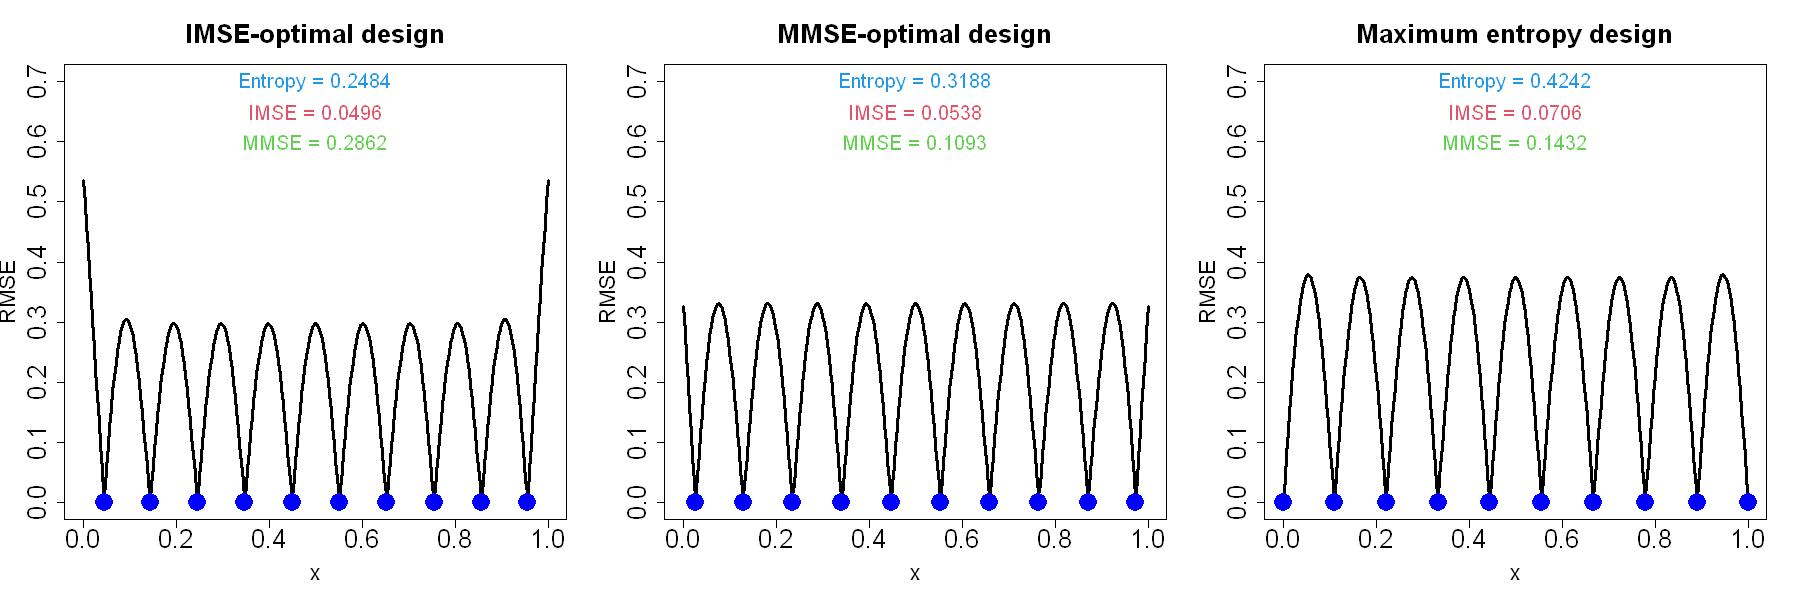

In [1]:
# 图 3.4

r=function(x,D)exp(-(outer(x,D,"-")/theta)^2)
s=function(x){
  Z=solve(R+10^(-6)*diag(n),t(r(x,D)))
  sqrt(1-colSums(t(r(x,D))*Z))
}
imse=function(D){
  R=r(D,D)
  s=function(x){
    Z=solve(R+10^(-6)*diag(n),t(r(x,D)))
    1-colSums(t(r(x,D))*Z)
  }
  integrate(s,0,1)$val
}
mmse=function(D){
  R=r(D,D)
  s=function(x){
    Z=solve(R+10^(-6)*diag(n),t(r(x,D)))
    1-colSums(t(r(x,D))*Z)
  }
  test=seq(0,1,length=301)
  max(s(test))
}
ent=function(D){
  R=r(D,D)
  det(R)
}

## IMSE

options(repr.plot.width=15,repr.plot.height=5)
par(mfrow=c(1,3))
theta=.1
n=10
test=seq(0,1,length=301)
D0=((1:n)-.5)/n
a=optim(D0,imse,lower=rep(0,n),upper=rep(1,n),method="L-BFGS-B")
D=a$par
R=r(D,D)
sa=s(test)
plot(test,sa,"l",xlab="x",ylab="RMSE",ylim=c(0,.7),main="IMSE-optimal design",cex.main=2,cex.lab=1.7,cex.axis=2,lwd=3)
points(cbind(D,0),pch=16,col="blue",cex=3)
text(.5,.7,paste("Entropy =",round(ent(D),4)),cex=1.5,col=4)
text(.5,.65,paste("IMSE =",round(imse(D),4)),cex=1.5,col=2)
text(.5,.6,paste("MMSE =",round(mmse(D),4)),cex=1.5,col=3)

## MMSE

a=optim(D0,mmse,lower=rep(0,n),upper=rep(1,n),method="L-BFGS-B")
D=a$par
R=r(D,D)
sa=s(test)
plot(test,sa,"l",xlab="x",ylab="RMSE",ylim=c(0,.7),main="MMSE-optimal design",cex.main=2,cex.lab=1.7,cex.axis=2,lwd=3)
points(cbind(D,0),pch=16,col="blue",cex=3)
text(.5,.7,paste("Entropy =",round(ent(D),4)),cex=1.5,col=4)
text(.5,.65,paste("IMSE =",round(imse(D),4)),cex=1.5,col=2)
text(.5,.6,paste("MMSE =",round(mmse(D),4)),cex=1.5,col=3)

## Maximum entropy

a=optim(D0,function(D)-ent(D),lower=rep(0,n),upper=rep(1,n),method="L-BFGS-B")
D=a$par
R=r(D,D)
sa=s(test)
plot(test,sa,"l",xlab="x",ylab="RMSE",ylim=c(0,.7),main="Maximum entropy design",cex.main=2,cex.lab=1.7,cex.axis=2,lwd=3)
points(cbind(D,0),pch=16,col="blue",cex=3)
text(.5,.7,paste("Entropy =",round(ent(D),4)),cex=1.5,col=4)
text(.5,.65,paste("IMSE =",round(imse(D),4)),cex=1.5,col=2)
text(.5,.6,paste("MMSE =",round(mmse(D),4)),cex=1.5,col=3)
par(mfrow=c(1,1))

$$
\bigstar\;\diamond\;\bigstar\quad\boxed{\sigma_{\omega}\sigma}\quad\bigstar\;\diamond\;\bigstar
$$